# Notebook for computing scalar measures of non-normality

In [11]:
import os
os.environ['OMP_NUM_THREADS'] = '16'
os.environ['MKL_NUM_THREADS'] = '16'
os.environ['OPENBLAS_NUM_THREADS'] = '16'

# Compute energy-growth inputs and build reduced mass matrix (global + BCs applied)
import numpy as np
import scipy
from scipy import sparse
import h5py
from lin_ops_full_reduction import Matrix, build_reduction_mapping, make_global_mat
import matplotlib.pyplot as plt

In [12]:
data_dir = '/mnt/homes/sfreiberger/research/recon_data/psc_data/harris_linear_20x6z/data'
massmat_path = f'{data_dir}/mass_mat.h5'
jacobian_path = f'{data_dir}/lin_ops.h5'

In [13]:

# keep_global includes both field-block selection and BC filtering
nr_local, keep_global = build_reduction_mapping(jacobian_path)

mass_local = Matrix(massmat_path, '/massmat')
jac = Matrix(jacobian_path, '/jacobian')

# Expand scalar mass matrix to the 7-field global state and map to global indexing
mmat_big = scipy.sparse.block_diag([mass_local.csr_rep] * 7, format='csr')
mmat_gl = make_global_mat(mmat_big.toarray(), nrg=jac.nrg, ncg=jac.ncg, lg=jac.lg)
mmat_gl = sparse.csr_array(mmat_gl)
mmat_gl.eliminate_zeros()
# Reduced mass matrix with global assembly and boundary conditions applied
reduced_mmat = mmat_gl[keep_global][:, keep_global].tocsr()

nrg_block = jac.nrg // 7
#slice upper left 3x3 blocks to get the mass matrix for the velocity fields only
reduced_mmat_3x3 = reduced_mmat[:3*nrg_block, :3*nrg_block]


In [14]:

vec_arr = []
for i in range(0, 2000, 10):
    with h5py.File(f'{data_dir}/xmhd2d_{i:05d}.rst', 'r') as f:
        vx = np.array(f['U_velx'][:])
        vy = np.array(f['U_vely'][:])
        vz = np.array(f['U_velz'][:])
        vec_arr.append(np.concatenate([vx.ravel(), vy.ravel(), vz.ravel()]))
        
states = np.array([vec.T@reduced_mmat_3x3@vec for vec in vec_arr])

e = states/2


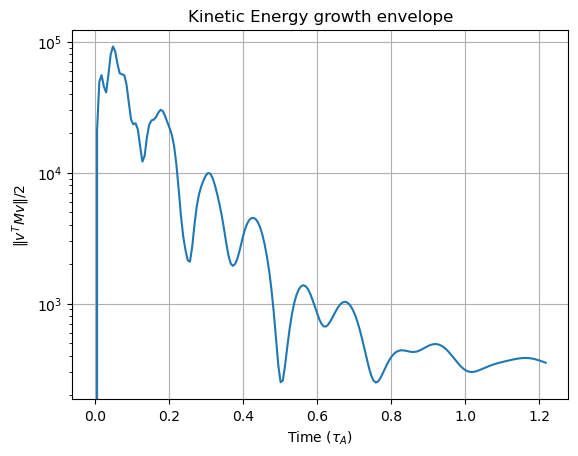

In [19]:

#plot the energy gdrowth envelope
dt = 1e-7/0.00001634796
t = np.arange(0, len(states)*dt, dt)
plt.plot(t, e)
plt.yscale('log')
plt.xlabel(r'Time ($\tau_A$)')
plt.ylabel(r'$\|v^TMv\|/2$')
plt.title('Kinetic Energy growth envelope')
plt.grid()  
plt.show()

In [16]:
# Map Jacobian to global indexing
jac_gl = make_global_mat(jac.csr_rep.toarray(), nrg=jac.nrg, ncg=jac.ncg, lg=jac.lg)
jac_gl = sparse.csr_array(jac_gl)
jac_gl.eliminate_zeros()

# Reduced mass matrix and Jacobian with global assembly and boundary conditions applied
reduced_mmat = mmat_gl[keep_global][:, keep_global].tocsr()
reduced_jac = jac_gl[keep_global][:, keep_global].tocsr()
identity = sparse.eye(reduced_jac.shape[0], format='csr')

real_jacobian = sparse.linalg.spsolve(reduced_jac, reduced_mmat.toarray())
real_jacobian -= identity
real_jacobian /= 1e-7

In [17]:
# compute the scalar measures
frob_square = (np.linalg.norm(real_jacobian, 'fro'))**2
print(f'Frobenius norm of the square: {frob_square}')
spectral_square = (np.linalg.norm(real_jacobian, 2))**2
print(f'Square of the spectral norm: {spectral_square}')
diff = (np.conj(real_jacobian).T @ real_jacobian) - (real_jacobian @ np.conj(real_jacobian).T)
frobenius_norm = np.linalg.norm(diff, 'fro')/frob_square
spectral_norm = np.linalg.norm(diff, 2)/spectral_square
print(f'Frobenius norm: {frobenius_norm}')
print(f'Spectral norm: {spectral_norm}')

Frobenius norm of the square: 1.4832639634657256e+35
Square of the spectral norm: 2.193716391619729e+32
Frobenius norm: 0.04192650533245247
Spectral norm: 1.000000000000009


In [28]:
#compute the least stable eigenvalue of the real Jacobian
least_eigvals, _ = sparse.linalg.eigs(real_jacobian, k=10, which='SR', tol=1e-8)
print(f'Least stable eigenvalue: {least_eigvals}')

Least stable eigenvalue: [-9365129.51224198+0.j -9365130.04796753+0.j -9362810.25199663+0.j
 -9362811.06272314+0.j -9362811.09440421+0.j -9364537.88616674+0.j
 -9364536.53760278+0.j -9364536.28591706+0.j -9364536.28342333+0.j
 -9360120.05571883+0.j]


In [27]:
print(least_eigvals)

[-11072.85032385+210756.29124859j -11072.85032385-210756.29124859j
    -26.88503977     +0.j            -27.86840057     +0.j
   -106.75976618     +0.j           -701.47067687     +0.j
  -1438.06774017     +0.j          -2611.28139208     +0.j
  -3639.2173717      +0.j          -5462.24585641     +0.j        ]
